#J381M_H13_visual

Shengchun Huang

2026-04-09


---




# Objective

Welcome back to J381M! This is the last tutorial session in this semester, and we are going to explore the world of computational visual analysis.

Before we dive into the technical details, we need to understand some basic principles for computational visual analysis.


# Understanding image elements

From previous classes on text analysis, we learned that computer can turn long texts into tokens, and then predict the likelihood of certain combination of tokens for an essay (i.e., semantic themes). But how does a computer read images?


Briefly, computer reads an image by separating it into millions of small dots, called pixels.

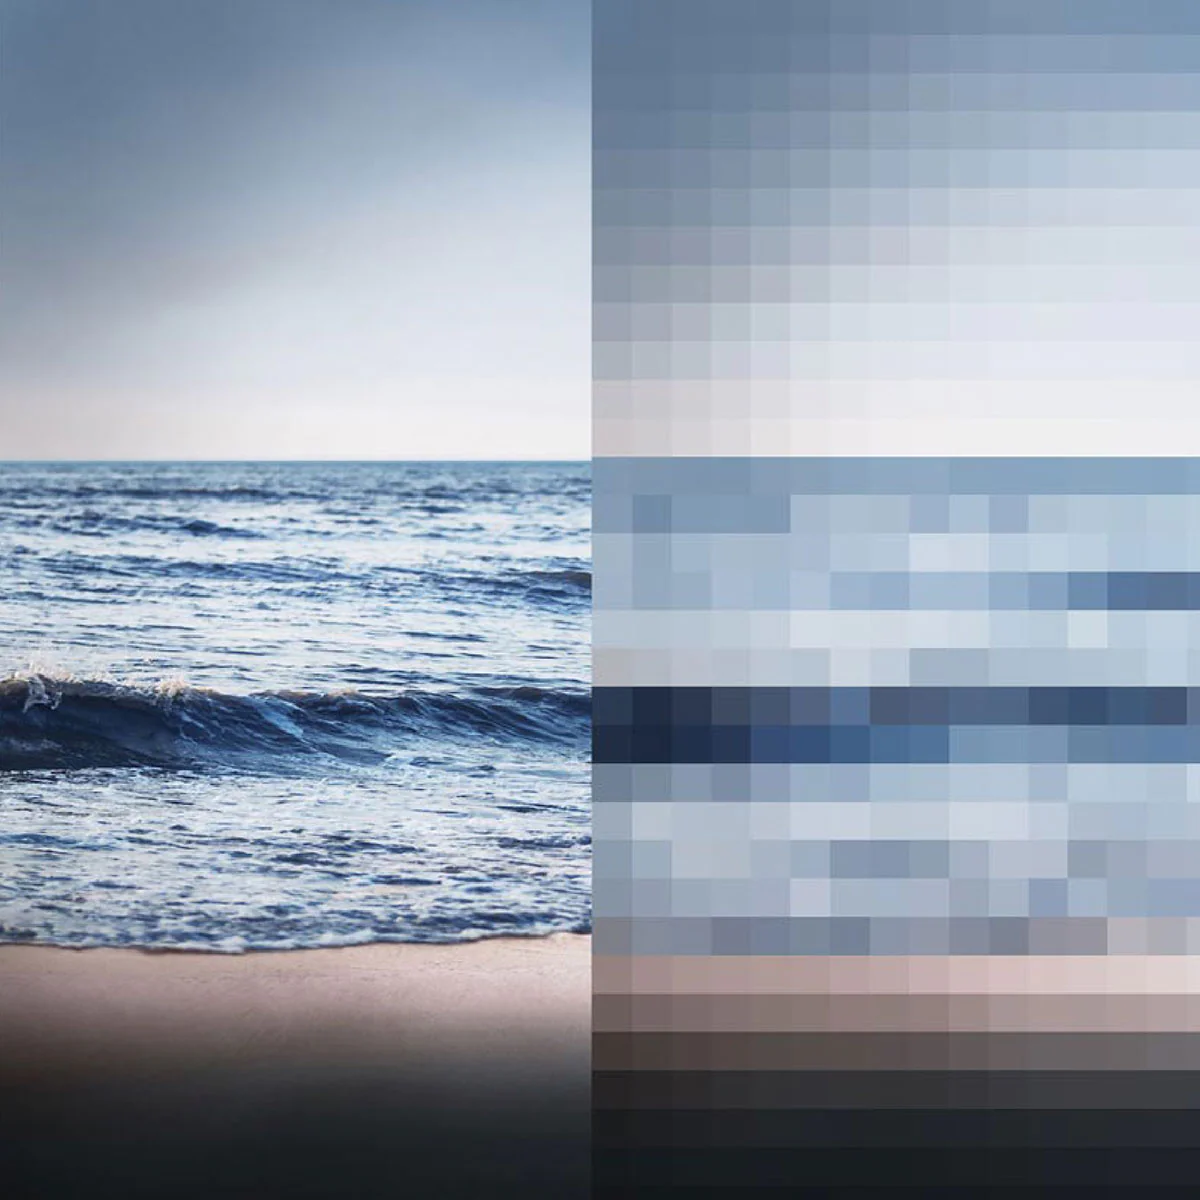

*   High-resolution images have more pixels, thus larger size.
*   Pixels are made of combinations of primary colors represented by a series of code.
*   Each pixel has a color, and each color has three channels (RGB).







# Demo 1: Understanding Color Channels

In [26]:
# mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

#import libraries
import cv2 as cv
from google.colab.patches import cv2_imshow #for colab,you need to use this

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
#read the image
image = cv.imread('/content/drive/MyDrive/Colab Notebooks/ComputerVisionTutorial/Composition with Red Yellow and Blue Piet Mondrian.jpg')

# Check if the image was loaded successfully
if image is None:
    print('Error: Could not load the image. Please ensure the image file exists at the specified path.')
else:
    #convert the image to RGB (images are read in BGR in OpenCV)
    RGB = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    #print the image array
    print(RGB)
    print('')

[[[200 200 184]
  [204 205 188]
  [211 212 195]
  ...
  [241  77  73]
  [246  83  79]
  [251  88  84]]

 [[204 205 188]
  [209 209 193]
  [216 216 200]
  ...
  [231  68  64]
  [238  75  71]
  [242  79  74]]

 [[211 212 195]
  [216 216 200]
  [222 222 206]
  ...
  [226  62  58]
  [231  68  64]
  [236  73  69]]

 ...

 [[ 28 112 168]
  [  0  83 139]
  [  0  78 133]
  ...
  [236 218 108]
  [235 217 107]
  [234 215 106]]

 [[  0  84 140]
  [ 17 102 157]
  [  5  92 147]
  ...
  [236 218 108]
  [234 215 106]
  [233 214 104]]

 [[  7  91 147]
  [  7  91 147]
  [  5  92 147]
  ...
  [235 217 107]
  [234 215 106]
  [232 213 103]]]



**Explanation:**

`[200 200 184]`
Each of the bracket represents a pixel in the image. And the three numbers show the intensity of Red, Green, Blue (RGB) channels.

In [28]:
#print the shape of the image array
print(RGB.shape)

(401, 400, 3)


**Explanation:**

Check the image info on your desktop. You will find the first two numbers are exactly the same as the dimension numbers. In this case: 401 x 400. It means that the computer maps the image as a grid with 401 rows and 400 columns of pixels.

The third number represents the "depth" of the array. For a standard color image, each individual pixel isn't just one number; it's an array of 3 values representing the intensity of Red, Green, and Blue (RGB). These values typically range from 0 to 255.


blue channel:


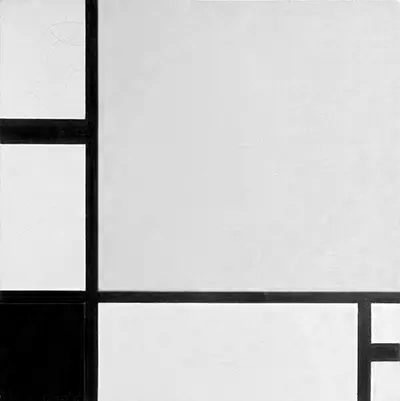

red channel:


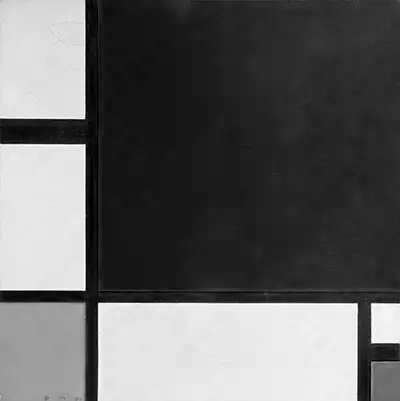

In [29]:
#split the image into its three channels
(R,G,B) = cv.split(image)

#display the images
print("blue channel:")
cv2_imshow(B)  #blue channel
print("red channel:")
cv2_imshow(R)  #red channel

# #create named windows for each of the images we are going to display
# cv.namedWindow("Blue", cv.WINDOW_NORMAL)
# cv.namedWindow("Green", cv.WINDOW_NORMAL)
# cv.namedWindow("Red", cv.WINDOW_NORMAL)
# #display the images
# cv.imshow("Blue",B)
# cv.imshow("Green", G)
# cv.imshow("Red", R)

**Explanation:**
I used the art piece from Piet Mondrian because it has distinct blue and yellow in the piece and easier to see the comparison.
In the original file, the upper right squre is red. That's the reason why you can see that the square is darker in the red channel, but ligher in the blue channel.

**Reference for Demo1:**

https://medium.com/featurepreneur/understanding-the-concept-of-channels-in-an-image-6d59d4dafaa9


# Demo 2: Your first visual analysis



Now, let's do some simple practice with visual analysis. Below are two images. How do you see the differences between them?

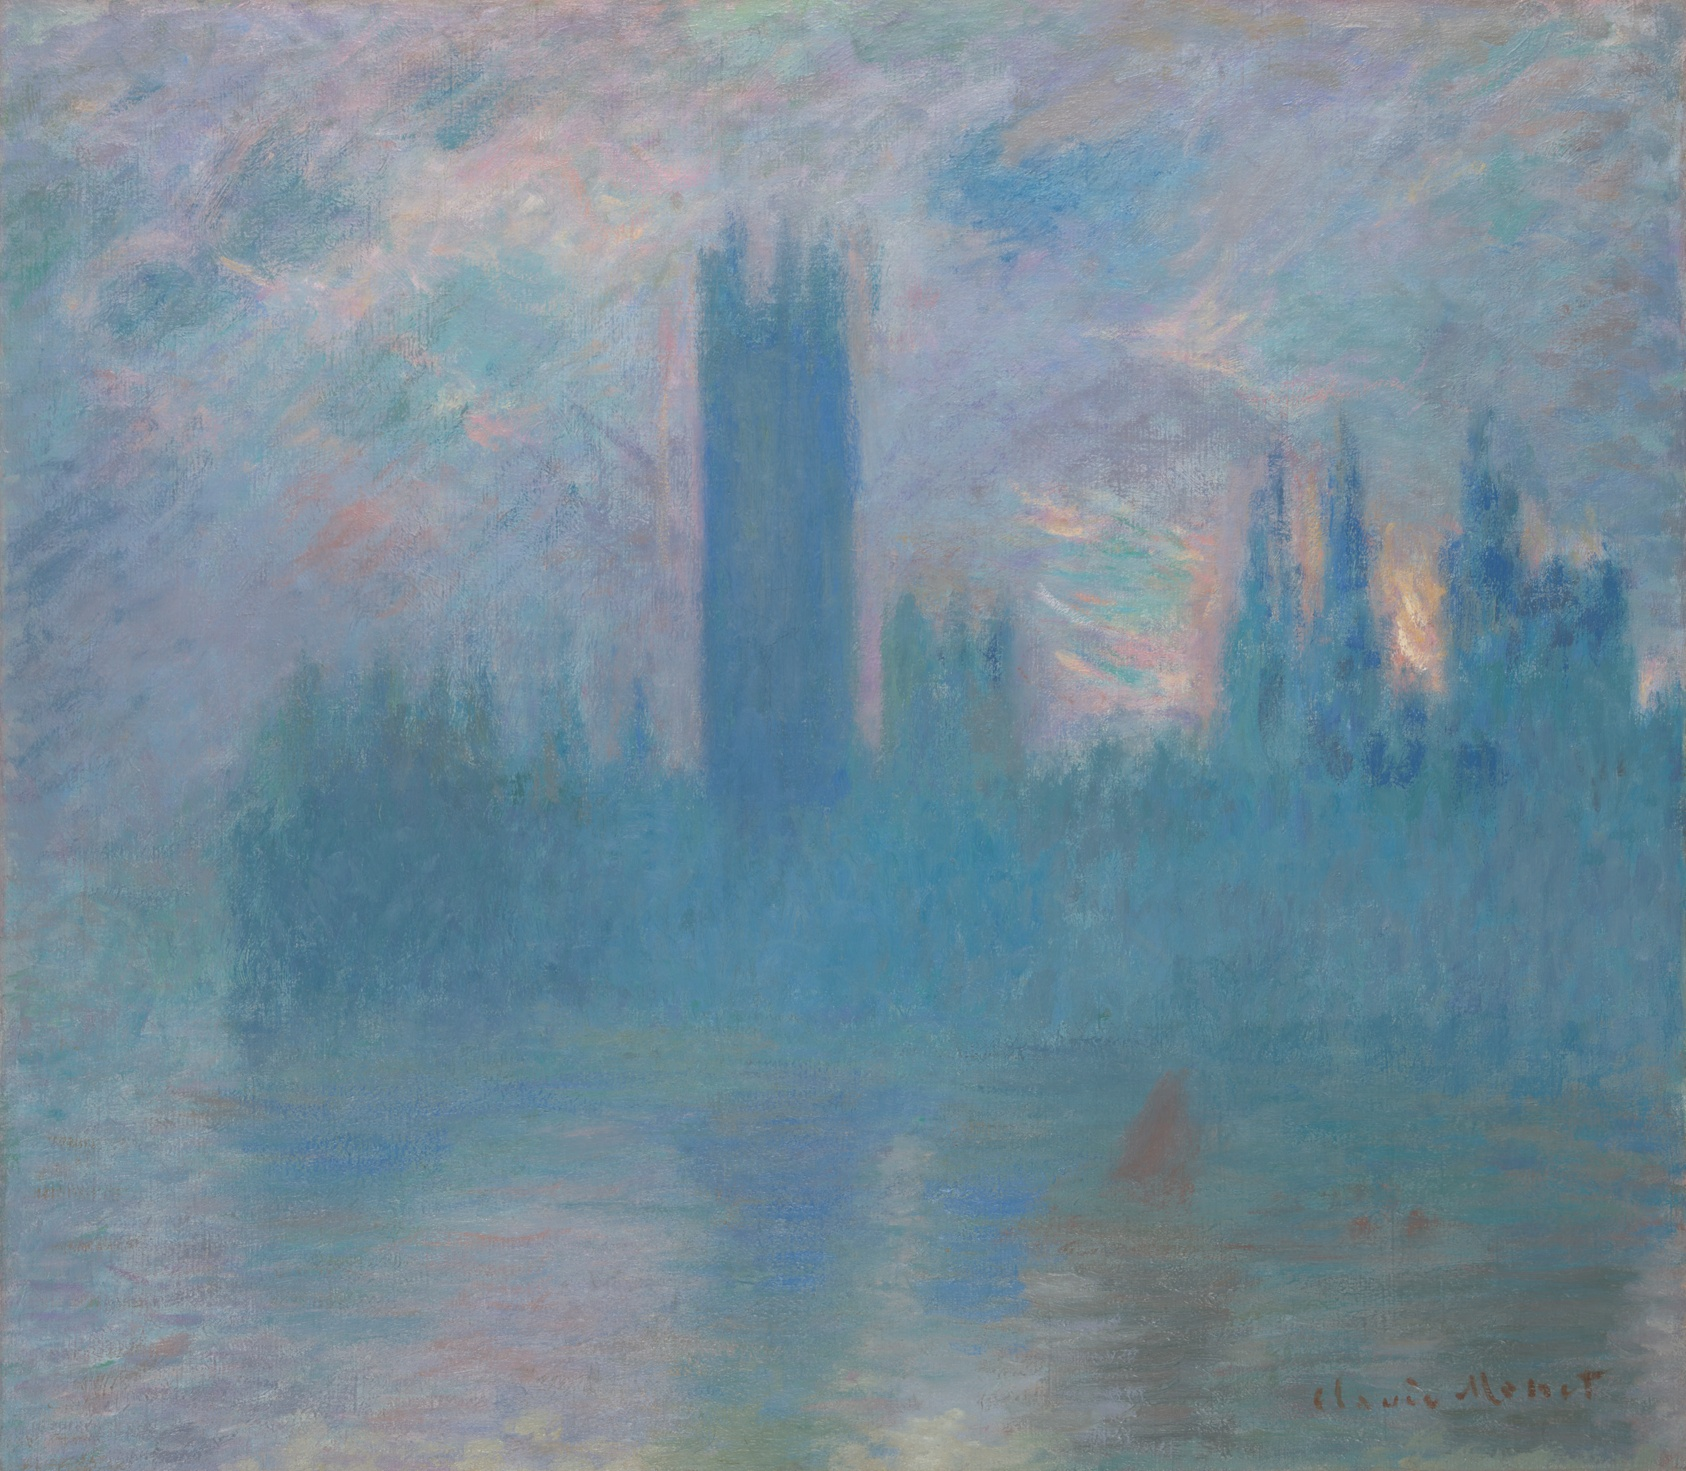

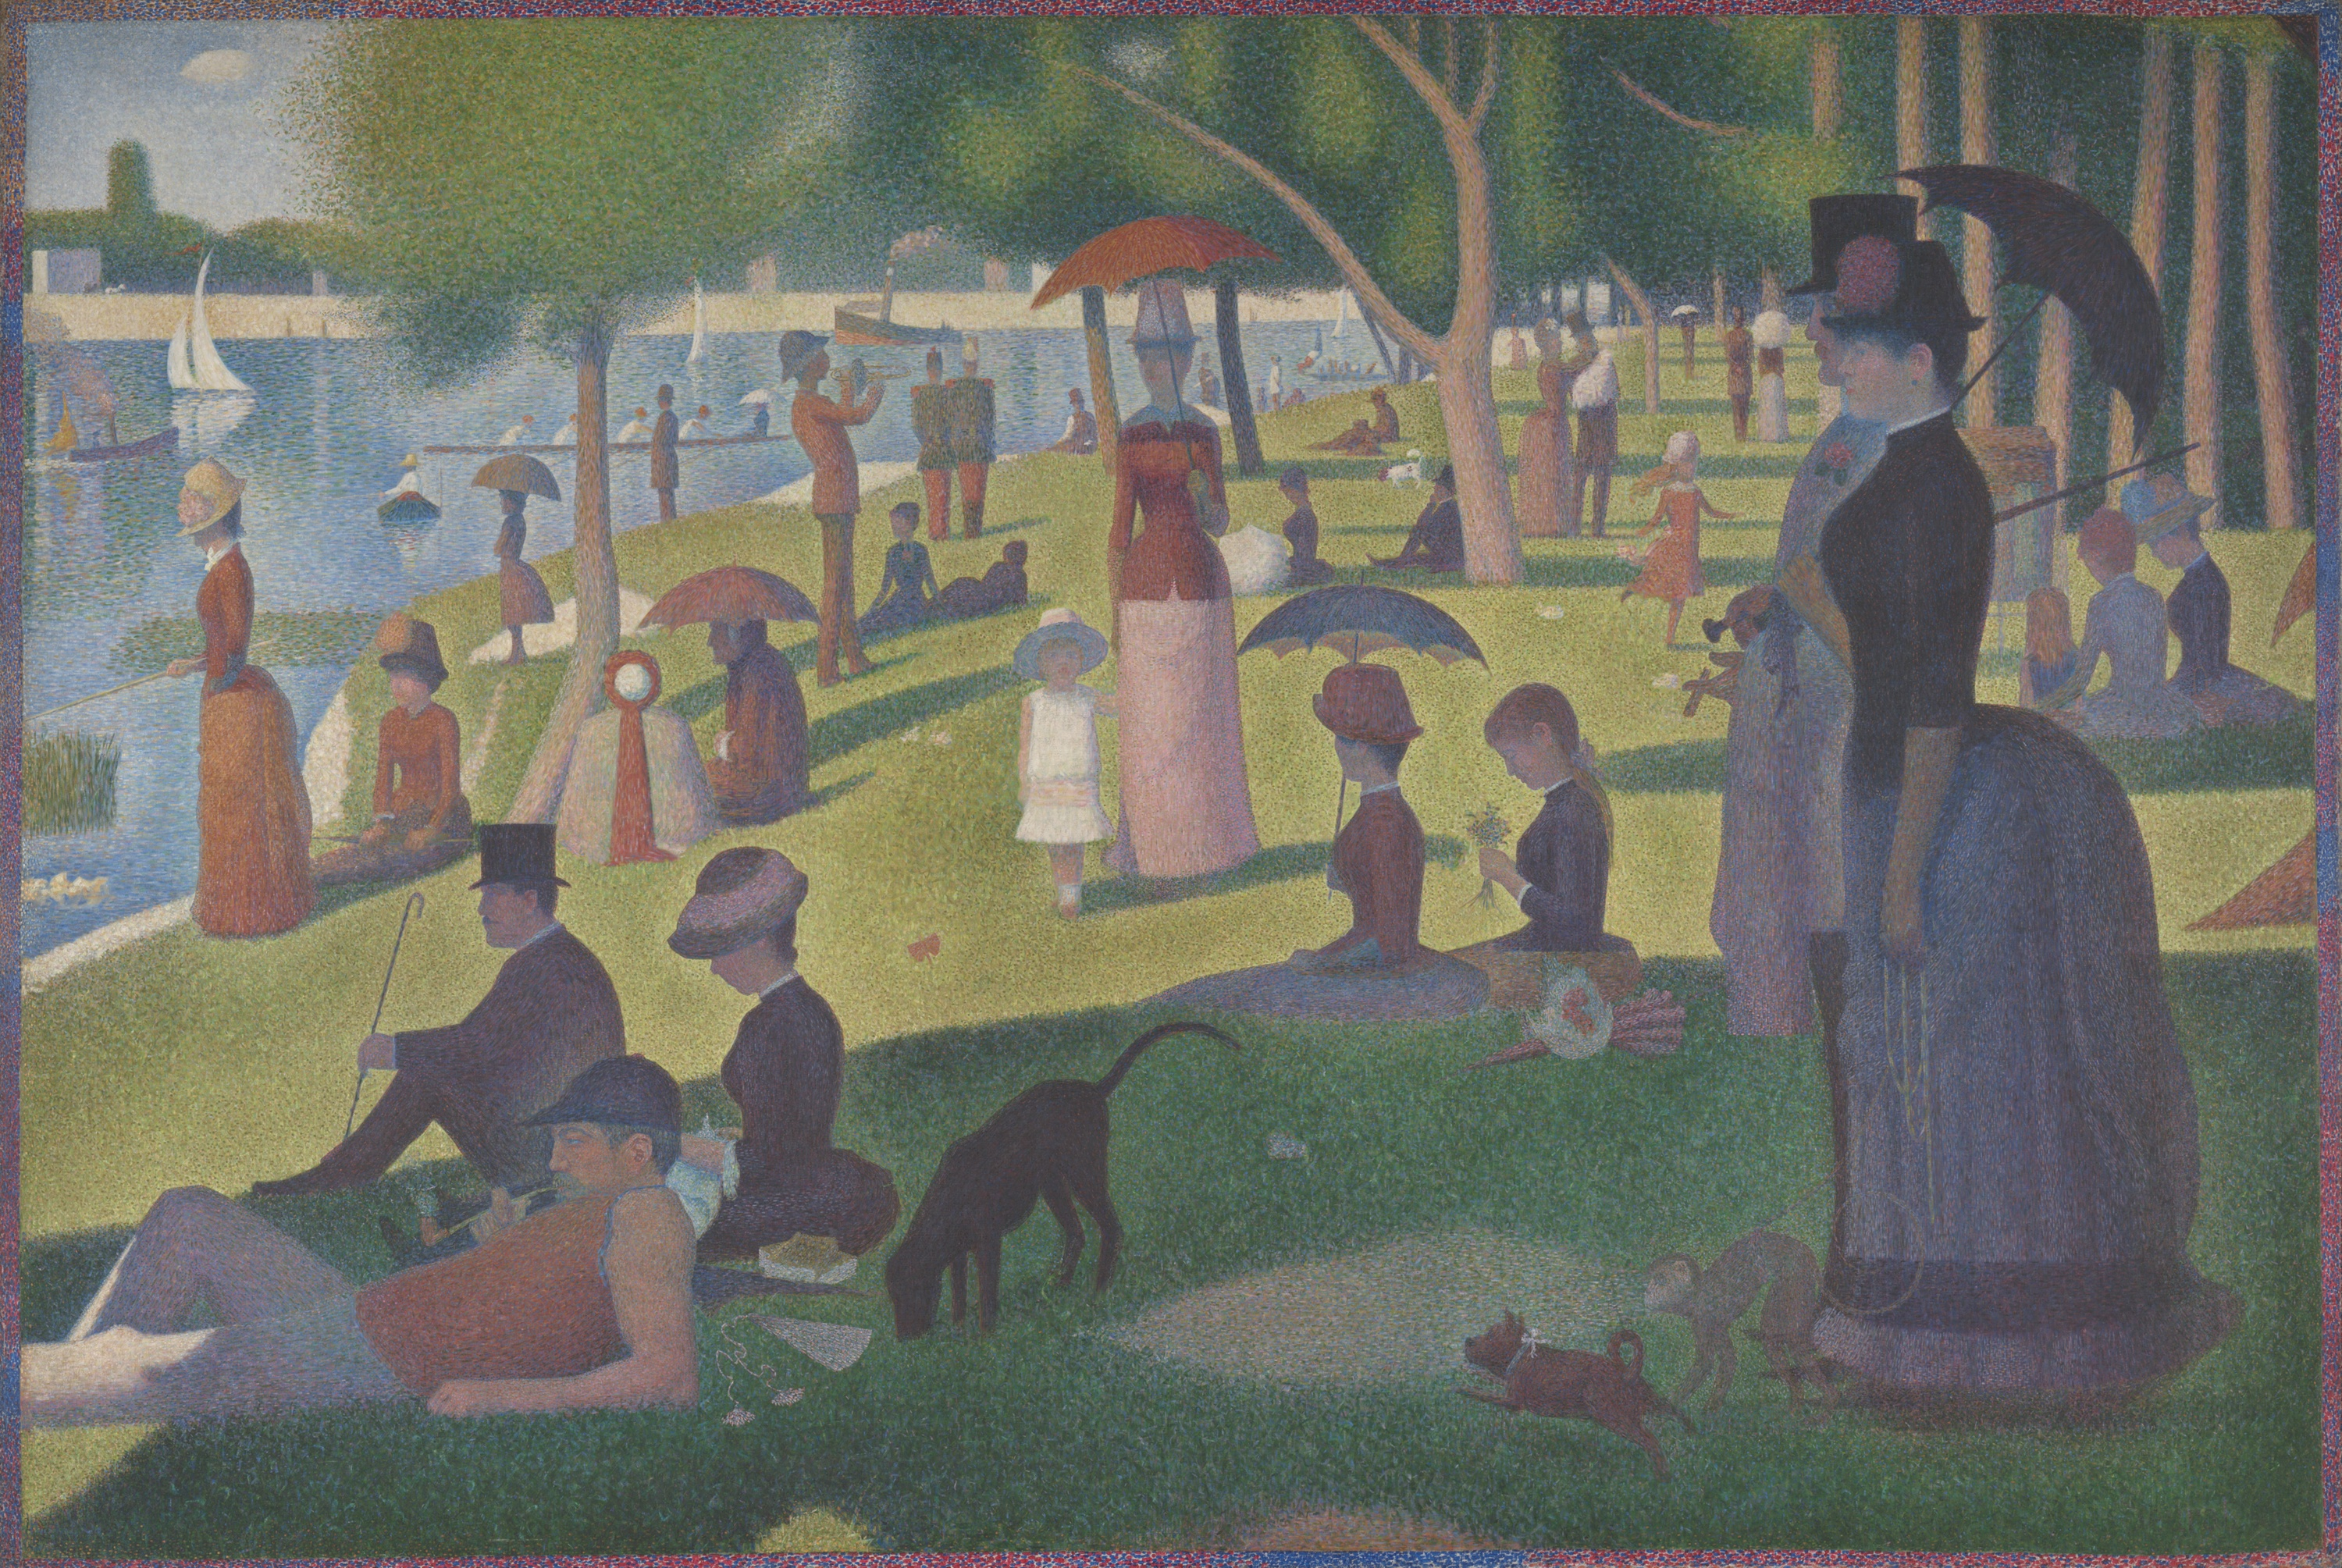





We have many ways to analyze the differences between these images: by counting how many humans in each image, comparing the aesthetic styles, and even our perceived feelings as viewers.

Here, we provide two lens to conduct the analysis:


1.   Visual variety
2.   Visual complexity



# Visual Variety

What does visual variety mean? In this specific tutorial, visual variety refers to the diversity of colors in an image.

The algorithm (based on Ke et al., 2006) looks at an image and counts how many distinct base colors (hues) are present.

For example,

*   Low Visual Variety: An image of a clear blue sky or a minimalist black-and-white portrait. The algorithm will only find 1 or 2 distinct hues.

*   High Visual Variety: A photo of a busy fruit market or a colorful abstract painting. The algorithm will find many distinct hues.

Now, let's give a try with the two images using the package of Athec in python. (https://github.com/yilangpeng/athec)


In [30]:
# 1. Install standard required packages
!pip install pyemd

# 2. Download the Athec code folder directly from GitHub
!git clone https://github.com/yilangpeng/Athec.git /content/Athec

# 3. Tell Python to look in our newly downloaded folder for the code
import sys
sys.path.append('/content/Athec')

# 4. Import the libraries we need!
from athec import misc, color, colordict
import pandas as pd
import numpy as np
import json


fatal: destination path '/content/Athec' already exists and is not an empty directory.


In [31]:
#import images
img1 = '/content/drive/MyDrive/Colab Notebooks/ComputerVisionTutorial/Parliament.jpg'
img2 = '/content/drive/MyDrive/Colab Notebooks/ComputerVisionTutorial/1926.224 - A Sunday on La Grande Jatte — 1884.jpg'

In [32]:
#resizing images for computing efficiency
resize_path1 = '/content/Parliament_resize.jpg'
resize_path2 = '/content/1926.224 - A Sunday on La Grande Jatte — 1884_resize.jpg'

result1 = misc.tf_resize(img1, resize_path1, max_side = 300)
misc.printd(result1)

result2 = misc.tf_resize(img2, resize_path2, max_side = 300)
misc.printd(result2)

{'file_size_original': 738651,
 'width_original': 1686,
 'height_original': 1471,
 'file_size_resize': 24331,
 'width_resize': 300,
 'height_resize': 262}
{'file_size_original': 2575514,
 'width_original': 3000,
 'height_original': 2009,
 'file_size_resize': 29935,
 'width_resize': 300,
 'height_resize': 201}




**Hue:** refers to the origin of the color we see. Think of the Hue as one of the six Primary and Secondary colors. In other words, the underlying base color of the mixture you're looking at is either Yellow, Orange, Red, Violet, Blue or Green.

![picture](https://color-wheel-artist.com/thrive/wp-content/uploads/2017/02/hue-color-wheel-featured.jpg)

In [33]:
# This function calculates "visual variety" by counting how many distinct, vibrant base colors (hues) exist in the image.

result_hue1 = color.attr_hue_count(
    resize_path1,                                # this is the input image that we are analyzing
    save_path = '/content/Parliament_hue.jpg',   # we save the output visualization as a new file
    saturation_low = 0.2,                        # this means we only count pixels with at least 20% color saturation (ignores grays)
    value_low = 0.15,                            # this means we only count pixels with at least 15% brightness (ignores blacks/dark shadows)
    value_high = 0.95,                           # this means we ignore pixels brighter than 95% (ignores pure whites/glare)
    hue_count_alpha = 0.05                       # Here we set up a threshold on hue alpha: A specific hue must make up at least 5% of the image to be counted as a "distinct" color
)

# Print the final count of distinct colors found in the image
misc.printd(result_hue1)


{'hue_count': 2}


How to interpret this result we get? The algorithm found only 2 distinct hues. This indicates low visual variety. The image is heavily dominated by the warm, golden tones of the sunset and dark silhouettes. Because the overall color palette is so restricted, only a couple of base colors meet our 5% threshold.

Now, let's take a look at the second image.

In [34]:
result_hue2 = color.attr_hue_count(resize_path2,
                              save_path = '/content/1926.224 - A Sunday on La Grande Jatte — 1884_hue.jpg',
                              saturation_low = 0.2,
                              value_low = 0.15,
                              value_high = 0.95,
                              hue_count_alpha = 0.05)
misc.printd(result_hue2)

{'hue_count': 13}


Here, the algorithm found 13 distinct hues. This indicates high visual variety. This famous pointillist painting uses a vibrant, wide-ranging spectrum of colors (greens, blues, reds, yellows, etc.) across the scene, resulting in a much higher count of distinct base colors.

# Visual Complexity

Now, let's look at another dimension. In computer vision, Visual Complexity measures how "busy" or detailed an image is. A photo of a blank, smooth wall has low complexity, while a photo of a dense forest or a crowded city street has high complexity.

To measure this busyness, the computer looks for Edges. This does not mean the same thing as the edges in network analysis. An edge in computer vision is anywhere in the image where there is a sharp, sudden change in brightness or color (like the dark outline of a building against a bright sky, or the lines of a person's face), like a border for the shape. More edges spread across the image generally mean higher visual complexity.

In [35]:
from athec import misc, edge, box
import numpy as np
np.int = int

In [36]:
# This chunk runs the visual complexity calculation on our image. It first finds the edges, then draws a box around them to measure how spread out they are.

# find the edges (borders) in the image
edges = edge.tf_edge_canny(
    resize_path1,                                # the input image we are analyzing
    save_path = '/content/default_edge1_1.jpg',  # we save the black-and-white edge sketch
    thresholds = None,                           # we let the computer decide the best contrast threshold
    otsu_ratio = 0.5,                            # automatically calculates the optimal light/dark boundary for edges
    gaussian_blur_kernel = (5, 5)                # applies a slight blur first to ignore tiny, noisy details
)

# now we measure the spread of those edges to determine complexity
result = edge.attr_complexity_edge_box(
    edges,                                       # The edge sketch we just created in Step 1
    save_path = '/content/default_edge2_1.jpg',  # Where to save the visualization (the image with the box drawn on it)
    min_perentage = 0.9,                         # Draw the smallest possible box that contains at least 90% of the edges
    check_interval = 1                           # Search pixel-by-pixel for the most precise box boundary
)

# Print the final complexity results, including the size of the bounding box!
misc.printd(result)


{'edge_box_size': 0.0013358778625954199,
 'edge_box_x1': 246,
 'edge_box_y1': 106,
 'edge_box_x2': 252,
 'edge_box_y2': 120}


### We visualize the complexity of image 1 like this:

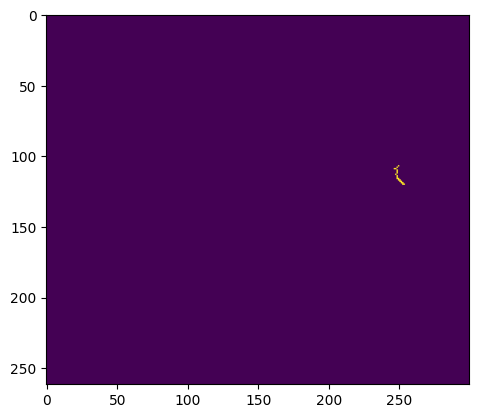

In [37]:
from matplotlib import pyplot as plt
from matplotlib import image as mpimg
image = mpimg.imread('/content/default_edge1_1.jpg.png')
image
plt.imshow(image)
plt.show()

### Similarly, we visualize the complexity of image 2 like this:

In [38]:
# from Athec import misc, edge, box
edges = edge.tf_edge_canny(resize_path2,
                           save_path = '/content/default_edge1_2.jpg',
                           thresholds = None,
                           otsu_ratio = 0.5,
                           gaussian_blur_kernel = (5,5))


result = edge.attr_complexity_edge_box(edges,
                                      save_path = '/content/default_edge2_2.jpg',
                                      min_perentage = 0.9,
                                      check_interval = 1)

misc.printd(result)

{'edge_box_size': 0.7117744610281924,
 'edge_box_x1': 1,
 'edge_box_y1': 1,
 'edge_box_x2': 296,
 'edge_box_y2': 145}


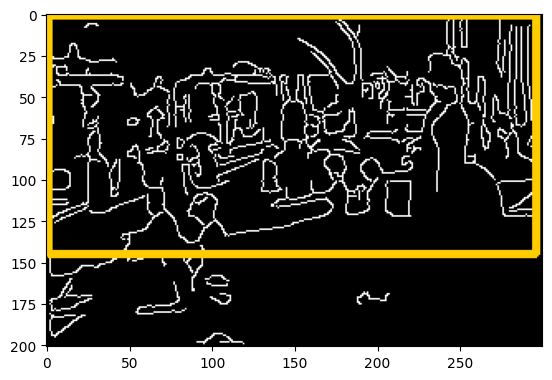

In [39]:
image = mpimg.imread('/content/default_edge2_2.jpg.png')
image
plt.imshow(image)
plt.show()

# CNNs in Computer Vision

In the previous demos, we explicitly told the computer how to analyze an image. We gave it strict rules: "count the base colors" (Variety) or "draw a box around the sharp contrast lines" (Complexity). This is called manual feature extraction.

But what if we want the computer to recognize a cat? It's almost impossible to write a manual rule for every shape, color, and size a cat could be.

This is where **Convolutional Neural Networks (CNNs)** come in. A CNN is a type of artificial intelligence designed specifically for visual data. Instead of researchers telling the computer what features to look for, a CNN learns the features itself by looking at thousands of examples.

How does it work?
Remember the edge detection blur we just used? A CNN does something very similar! It passes a mathematical filter (called a "convolution") over the image, scanning it pixel by pixel.



*   Early layers look for simple patterns: vertical edges, horizontal edges, and color blobs.
*   Middle layers combine those edges to find shapes: circles, squares, or textures.
*   Final layers combine those shapes into recognizable objects: "this combination of shapes looks like a cat ear and a tail!"


What does this mean for computational visual analysis?
CNNs completely revolutionized the field. They shifted visual analysis from rigid, human-made rules to flexible, machine-learned patterns. This is the technology powering the most advanced computer vision tasks today, including:

*   Image Classification: Automatically tagging photos on your phone (e.g., searching "dog" in your camera roll).

*   Medical Imaging: Scanning X-rays or MRIs to detect early signs of tumors faster than a human doctor.

*   Autonomous Vehicles: Allowing self-driving cars to recognize stop signs, lane lines, and pedestrians in real-time.

### An interactive playground for CNNs

To really understand how a CNN "sees" the world, let's play with a few visual simulators!

https://adamharley.com/nn_vis/cnn/2d.html


For extended learning on CNNs, please visit: https://poloclub.github.io/cnn-explainer/#article-relu


# Acknowledgement

This tutorial material is developed building on materials shared by our incoming Assistant Professor, Yibing Sun. Please feel free to consult her for more questions about computer visaul analysis.

The package we are using for computational visual analysis was developed by Prof. Yilang Peng at University of Georgia: https://github.com/yilangpeng/athec.